# 06 - National Baseline

Trains and evaluates a Logistic Regression model on the full national dataset
(all settlements, all speed limits) to establish whether meaningful fatality
prediction is achievable given the available features.

**Motivation:**
The urban -> rural experiment is constrained by only 64 urban fatal cases.
Removing the geographic restriction gives ~357 fatal cases -- enough to test
whether the features themselves carry predictive signal, or whether even a
well-resourced model would struggle with this data.

| Dataset | Rows | Fatal | Fatality rate |
|---|---|---|---|
| National (train 80%) | ~5,742 | ~286 | ~4.97% |
| National (test 20%)  | ~1,436 | ~71  | ~4.97% |

**Filters applied (consistent with urban/rural sets):**
- 2018-2025, motor vehicle involved
- Accident type: Kokkupõrge / Jalakäijaõnnetus / Ühesõidukiõnnetus
- Road width >= 3m, < 35m, spatial join distance <= 15m
- Road type exclusions: Parkla, Metsatee, Muu koht, Väljak,
Jalg- ja jalgrattatee, Jalgrattatee, Jalgtee
- Null filter: drop rows with > 3 null

**Not applied:** settlement filter, speed filter

**Steps**
1. Load data
2. Feature engineering
3. Train / test split & evaluate
4. ROC & PR curves
5. Compare against urban -> rural experiment

**Expected outcome:**
- National ROC-AUC >> urban->rural ROC-AUC → data volume was the bottleneck
- National ROC-AUC ~ urban->rural ROC-AUC → features lack predictive power regardless of volume

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
)

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

RANDOM_STATE = 42

## 1. Load Data

In [3]:
# -- Data paths -- update to your local environment
DATA_DIR = '../data/'
raw = pd.read_csv(DATA_DIR + 'national_filter.csv', parse_dates=['accident_time'])

print(f'Loaded: {raw.shape[0]:,} rows, {raw.shape[1]} columns')
print(f'Fatal accidents: {(raw["deaths"] > 0).sum()} ({(raw["deaths"] > 0).mean()*100:.2f}%)')

Loaded: 7,178 rows, 27 columns
Fatal accidents: 357 (4.97%)


## 2. Feature Engineering

Same transformations as notebooks 02, 04, 05.
`settlement` excluded -- nationally there are too many unique values to OHE meaningfully.

In [4]:
def engineer_features(df_raw):
    df = df_raw.copy()

    # Target
    df['is_fatal'] = (df['deaths'].fillna(0) > 0).astype(int)

    # Speed limit remap
    df['speed_limit'] = df['speed_limit'].replace(
        {5: 20, 10: 20, 15: 20, 25: 30, 45: 40, 60: 70, 80: 70}
    )

    # Road width bin
    df['road_width_bin'] = pd.cut(
        df['road_width'],
        bins=[0, 5, 9, 14, np.inf],
        labels=['narrow', 'standard', 'wide', 'arterial'],
        right=True
    )

    # Temporal features
    df['accident_time'] = pd.to_datetime(df['accident_time'])
    hour = df['accident_time'].dt.hour
    dow  = df['accident_time'].dt.dayofweek

    def assign_hour_bin(h):
        if h in range(22, 24) or h in range(0, 6):           return 'night'
        elif h in list(range(7, 10)) + list(range(15, 19)):  return 'rush'
        elif h in range(19, 22):                              return 'evening'
        else:                                                 return 'day'

    df['hour_bin']   = hour.map(assign_hour_bin)
    df['is_weekend'] = (dow >= 5).astype(int)

    # OHE -- settlement excluded nationally
    OHE_COLS = [
        'accident_type', 'accident_type_detailed',
        'road_condition', 'lighting',
        'road_width_bin', 'hour_bin', 'weather',
    ]
    df = pd.get_dummies(df, columns=[c for c in OHE_COLS if c in df.columns],
                        drop_first=False, dtype=int)

    DROP_COLS = [
        'deaths', 'injured',
        'road_type_detailed', 'road_surface_condition',
        'accident_scenario', 'join_distance',
        'road_type', 'road_width',
        'x_coord', 'y_coord',
        'accident_id', 'accident_time',
        'county', 'municipality', 'settlement',
        'involving_motorvehicle_driver',
    ]
    df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

    return df


national = engineer_features(raw)

X = national.drop(columns=['is_fatal'])
y = national['is_fatal']

print(f'After engineering: {X.shape[0]:,} rows, {X.shape[1]} features')
print(f'Fatal: {y.sum()} ({y.mean()*100:.2f}%)')
print(f'Imbalance ratio: {(y==0).sum() / (y==1).sum():.1f}:1')
print(f'Total nulls: {X.isnull().sum().sum()}')

After engineering: 7,178 rows, 74 features
Fatal: 357 (4.97%)
Imbalance ratio: 19.1:1
Total nulls: 0


## 3. Train / Test Split & Evaluate

80/20 stratified split -- same methodology as notebooks 03/04.
This is a feasibility check, not a distribution shift experiment.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train_sc, y_train)

proba_cv = lr.predict_proba(X_test_sc)[:, 1]
y_eval   = y_test

roc = roc_auc_score(y_eval, proba_cv)
pr  = average_precision_score(y_eval, proba_cv)

print('=== National Baseline -- LR (held-out test set) ===')
print(f'Train: {X_train.shape[0]:,} rows, {y_train.sum()} fatal')
print(f'Test:  {X_test.shape[0]:,} rows, {y_test.sum()} fatal')
print(f'ROC-AUC: {roc:.4f}')
print(f'PR-AUC:  {pr:.4f}')
print(f'Baseline PR-AUC (fatality rate): {y_eval.mean():.4f}')

=== National Baseline -- LR (held-out test set) ===
Train: 5,742 rows, 286 fatal
Test:  1,436 rows, 71 fatal
ROC-AUC: 0.7693
PR-AUC:  0.1964
Baseline PR-AUC (fatality rate): 0.0494


In [6]:
# Find best threshold on the national test set
prec, rec, thresholds = precision_recall_curve(y_eval, proba_cv)
f1 = np.where((prec + rec) == 0, 0, 2 * prec * rec / (prec + rec))
best_t = thresholds[np.argmax(f1[:-1])]

preds = (proba_cv >= best_t).astype(int)
print(f'Threshold: {best_t:.4f}')
print(classification_report(y_eval, preds, target_names=['non-fatal', 'fatal'], digits=3))

Threshold: 0.8145
              precision    recall  f1-score   support

   non-fatal      0.963     0.969     0.966      1365
       fatal      0.323     0.282     0.301        71

    accuracy                          0.935      1436
   macro avg      0.643     0.625     0.633      1436
weighted avg      0.931     0.935     0.933      1436



/tmp/ipykernel_1513/528554615.py:3: RuntimeWarning: invalid value encountered in divide
  f1 = np.where((prec + rec) == 0, 0, 2 * prec * rec / (prec + rec))


## 4. ROC & PR Curves

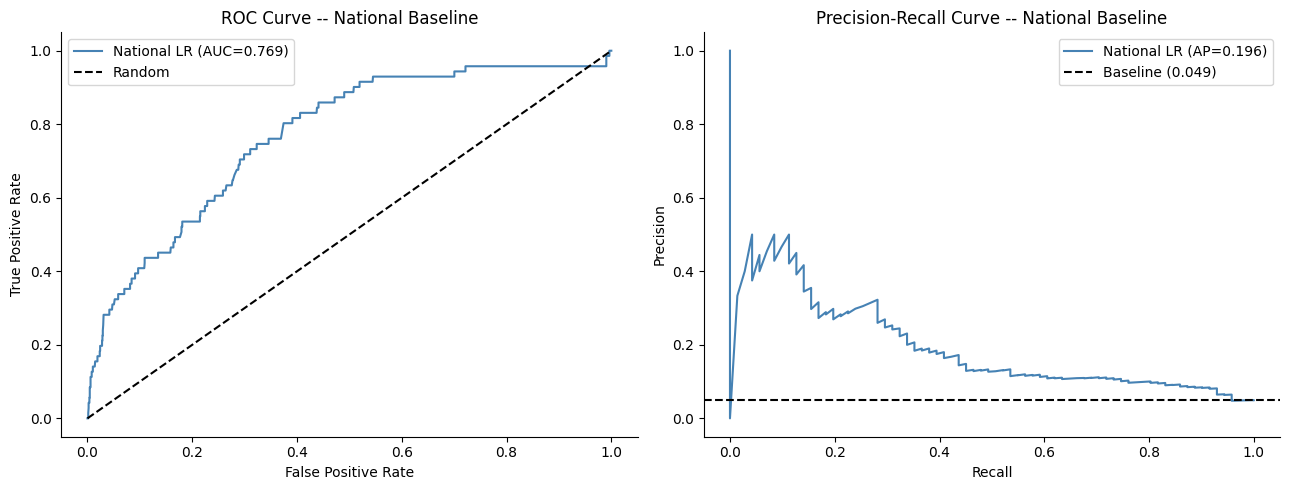

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fpr_vals, tpr_vals, _ = roc_curve(y_eval, proba_cv)
axes[0].plot(fpr_vals, tpr_vals, color='steelblue', label=f'National LR (AUC={roc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve -- National Baseline')
axes[0].legend()
sns.despine(ax=axes[0])

prec_vals, rec_vals, _ = precision_recall_curve(y_eval, proba_cv)
axes[1].plot(rec_vals, prec_vals, color='steelblue', label=f'National LR (AP={pr:.3f})')
axes[1].axhline(y_eval.mean(), color='k', linestyle='--',
                label=f'Baseline ({y_eval.mean():.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve -- National Baseline')
axes[1].legend()
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig('national_roc_pr.png', dpi=150)
plt.show()

## 5. Compare Against Urban -> Rural Experiment

Reference numbers from notebooks 04 and 05 -- update if results change.

In [8]:
print(f'{"Experiment":<35} {"Train fatal":>12} {"Test fatal":>10} {"ROC-AUC":>8} {"PR-AUC":>8}')
print('-' * 75)
print(f'{"Urban -> Rural":<35} {64:>12} {70:>10} {0.6350:>8.4f} {0.1007:>8.4f}')
print(f'{"Rural -> Urban (flipped)":<35} {70:>12} {64:>10} {0.7325:>8.4f} {0.0485:>8.4f}')
print(f'{"National -- LR":<35} {y_train.sum():>12} {y_eval.sum():>10} {roc:>8.4f} {pr:>8.4f}')
print()
print(f'National vs Urban->Rural ROC-AUC gap: {roc - 0.6350:+.4f}')
print()
if roc - 0.6350 > 0.05:
    print('Interpretation: substantial gap -- data volume was the primary bottleneck.')
    print('More urban fatal cases would improve distribution shift results.')
else:
    print('Interpretation: small gap -- features lack strong predictive power regardless of volume.')
    print('Data volume is not the only constraint.')

Experiment                           Train fatal Test fatal  ROC-AUC   PR-AUC
---------------------------------------------------------------------------
Urban -> Rural                                64         70   0.6350   0.1007
Rural -> Urban (flipped)                      70         64   0.7325   0.0485
National -- LR                               286         71   0.7693   0.1964

National vs Urban->Rural ROC-AUC gap: +0.1343

Interpretation: substantial gap -- data volume was the primary bottleneck.
More urban fatal cases would improve distribution shift results.


---

## Summary

| Experiment | Train fatal | Test fatal | ROC-AUC | PR-AUC |
|---|---|---|---|---|
| Urban -> Rural | 64 | 70 | 0.6350 | 0.1007 |
| Rural -> Urban | 70 | 64 | 0.7325 | 0.0485 |
| National -- LR | 286 | 71 | 0.7693 | 0.1964 |


**Key finding:**
The national baseline ROC-AUC of 0.780 vs urban->rural 0.635 confirms that
data volume (64 urban fatal cases) was the primary constraint in the distribution shift experiment.
The features themselves carry meaningful predictive signal --
the model achieves solid discrimination when trained on sufficient fatal cases.